In [16]:
import numpy as np
import matplotlib.pyplot as plt
import lmdb
import pickle
import statistics


In [17]:
npz_path = '/home/liud/Documents/code/ocp/results/is2rse/2025-04-17-21-11-28/is2rfse_predictions_0.npz'
test_path = '/media/liud/Liud_FX2T/dataset/OC20/is2re_100k/select_data/tags1&2/100k/test'
# train_path = '/media/liud/Liud_FX2T/dataset/OC20/is2re_10k/ac_stru/select_data_ads_dis1/train'

# 读取 npz 文件中的数据
data = np.load(npz_path)

# 提取 ids1, ids2 和 energy
sid = np.array(data['ids'].astype(int)) # sid
energy = np.array(data['energy'])

# energy 按照 sid排序
sorted_idx = np.argsort(sid)
sid_sorted = sid[sorted_idx].tolist()
energy_sorted = energy[sorted_idx].tolist()
print(sid_sorted)
print(energy_sorted)


[31, 225, 416, 1396, 1966, 2022, 3068, 3293, 3609, 6590, 7736, 12428, 13002, 13959, 14088, 14999, 16257, 17405, 19824, 20099, 22276, 24776, 24809, 25434, 25520, 26051, 26560, 27361, 30096, 31273, 31596, 35536, 39489, 40798, 41809, 42135, 42374, 44286, 44570, 44811, 47546, 47782, 48090, 50170, 50618, 51143, 51796, 51918, 52284, 55877, 56448, 56784, 57020, 57048, 57740, 57857, 58189, 59388, 59878, 60385, 62353, 62817, 63182, 63373, 65030, 67695, 68091, 68864, 69764, 71396, 71518, 72424, 72775, 76550, 77435, 77640, 78336, 78810, 80172, 80321, 80333, 80770, 82087, 83417, 84408, 85311, 86779, 87427, 89170, 90609, 91208, 92808, 93040, 94283, 94450, 94517, 95027, 95614, 98773, 103070, 103360, 103573, 104301, 104680, 105270, 105307, 106065, 108389, 109757, 110986, 116049, 117907, 118286, 118736, 119691, 120032, 124035, 128530, 128958, 131089, 131847, 132373, 133147, 133470, 139825, 141123, 143451, 144875, 145546, 151336, 152456, 153389, 153543, 154368, 156102, 158182, 163237, 166504, 167475, 1

In [18]:
# 打开 LMDB 文件
env = lmdb.open(test_path, readonly=True)

# 列表用于存储 (sid,  y) 元组
data_list = []

# 从 LMDB 文件中读取数据并提取 sid,和 y 值
with env.begin(write=False) as txn:
    cursor = txn.cursor()
    for key, value in cursor:
        info = pickle.loads(value)
        data_list.append((info.sid ,info.y))
        # data_list.append((info.sid, info.ads_id ,info.y))

# 关闭 LMDB 文件
env.close()

# 将数据转换为 numpy 数组以便于排序
data_array = np.array(data_list, dtype=[('sid', 'i4'), ('y', 'f8')])
# data_array = np.array(data_list, dtype=[('sid', 'i4'), ('ads_id','i4'), ('y', 'f8')])

# 按照 sid 和 fid 对 data_array 进行排序
sorted_data_array = np.sort(data_array, order=['sid'])

# 提取排序后的 sid、fid 和 y 值列表
sid_list = sorted_data_array['sid'].tolist()
test_energy_sorted = sorted_data_array['y'].tolist()

print("sid:", sid_list)
print("y:", test_energy_sorted)
print("Length:", len(test_energy_sorted))


sid: [31, 225, 416, 1396, 1966, 2022, 3068, 3293, 3609, 6590, 7736, 12428, 13002, 13959, 14088, 14999, 16257, 17405, 19824, 20099, 22276, 24776, 24809, 25434, 25520, 26051, 26560, 27361, 30096, 31273, 31596, 35536, 39489, 40798, 41809, 42135, 42374, 44286, 44570, 44811, 47546, 47782, 48090, 50170, 50618, 51143, 51796, 51918, 52284, 55877, 56448, 56784, 57020, 57048, 57740, 57857, 58189, 59388, 59878, 60385, 62353, 62817, 63182, 63373, 65030, 67695, 68091, 68864, 69764, 71396, 71518, 72424, 72775, 76550, 77435, 77640, 78336, 78810, 80172, 80321, 80333, 80770, 82087, 83417, 84408, 85311, 86779, 87427, 89170, 90609, 91208, 92808, 93040, 94283, 94450, 94517, 95027, 95614, 98773, 103070, 103360, 103573, 104301, 104680, 105270, 105307, 106065, 108389, 109757, 110986, 116049, 117907, 118286, 118736, 119691, 120032, 124035, 128530, 128958, 131089, 131847, 132373, 133147, 133470, 139825, 141123, 143451, 144875, 145546, 151336, 152456, 153389, 153543, 154368, 156102, 158182, 163237, 166504, 1674

In [19]:
# # 根据fid统计每个fid的平均绝对误差
# fid_mae_sum = [0] * 85
# fid_num = [0] * 85
# for e, t in zip(energy_sorted, sorted_data_array):
#     mae = abs(t[2]-e)
#     fid_mae_sum[t[1]] = fid_mae_sum[t[1]] + mae
#     fid_num[t[1]] = fid_num[t[1]] + 1
# fid_mae_avg = [0]*85
# for k,v in enumerate(fid_mae_sum):
#     if v>0:
#         fid_mae_avg[k] = v/ fid_num[k]
# # print(fid_mae_sum)
# # print(fid_num)
# print(fid_mae_avg)
# train_fid_num = [0]*85
# train_env = lmdb.open(train_path, readonly=True)
# with train_env.begin(write=False) as train_txn:
#     cursor = train_txn.cursor()
#     for key,value in cursor:
#         info = pickle.loads(value)
#         train_fid_num[info.fid] = train_fid_num[info.fid] + 1
# print(train_fid_num)
# a = []
# b = []
# for k,v in enumerate(fid_mae_avg):
#     if v > 0:
#         a.append(v)
#         b.append(train_fid_num[k])
# # plt.figure(figsize=(10, 6))  # 设置图像大小
# plt.scatter(b, a, marker='o', color='blue')  # 绘制折线图
# # 
# # plt.xlabel("INDEX")  # 设置横坐标标签
# # plt.ylabel("Efficient ")     # 设置纵坐标标签
# # plt.title("value 1")  # 设置图像标题
# # 
# # 
# # plt.xticks([])  # 设置横坐标刻度为正整数
# # 
# # plt.grid(True, which='both', linestyle='--', linewidth=0.5)  # 添加网格线
# # plt.tight_layout()  # 调整图像布局
# 
# plt.show()  # 显示图像

In [20]:
# 计算相对误差，及中位数
efficient = [abs((t - e) / t)  for e, t in zip(energy_sorted, test_energy_sorted)]
# efficient = [abs((t - e))  for e, t in zip(energy_sorted, test_energy_sorted)]
statistics.median(efficient)

0.16203383894424617

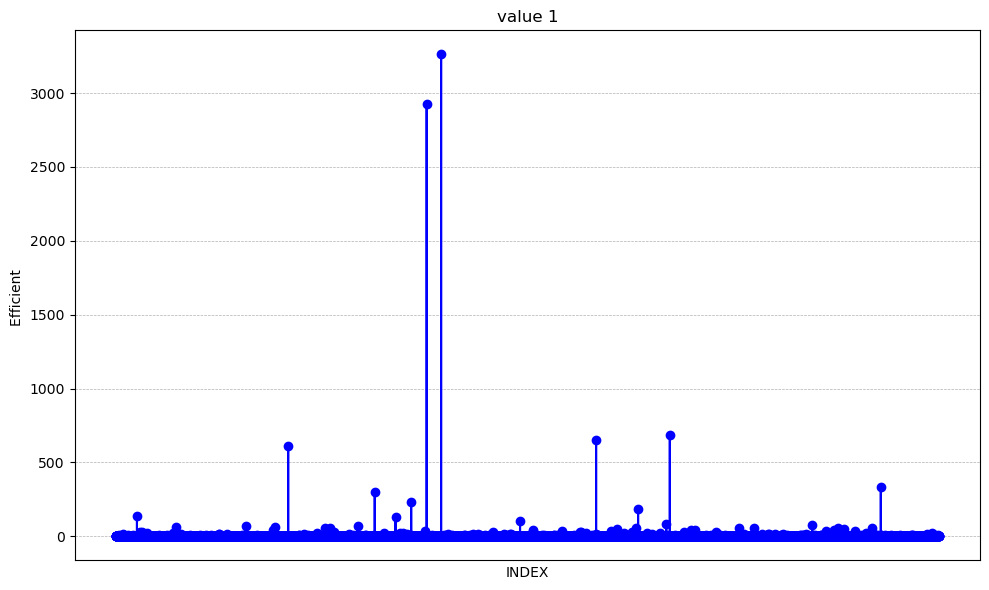

In [21]:
x = list(range(1, len(efficient) + 1))

plt.figure(figsize=(10, 6))  # 设置图像大小
plt.plot(x, efficient, marker='o', linestyle='-', color='b')  # 绘制折线图

plt.xlabel("INDEX")  # 设置横坐标标签
plt.ylabel("Efficient ")     # 设置纵坐标标签
plt.title("value 1")  # 设置图像标题


plt.xticks([])  # 设置横坐标刻度为正整数

plt.grid(True, which='both', linestyle='--', linewidth=0.5)  # 添加网格线
plt.tight_layout()  # 调整图像布局

plt.show()  # 显示图像

In [22]:
count_below_0_4 = sum(1 for value in efficient if value < 1)

# 计算比例
ratio = count_below_0_4 / len(efficient)
ratio

0.8949444245249193

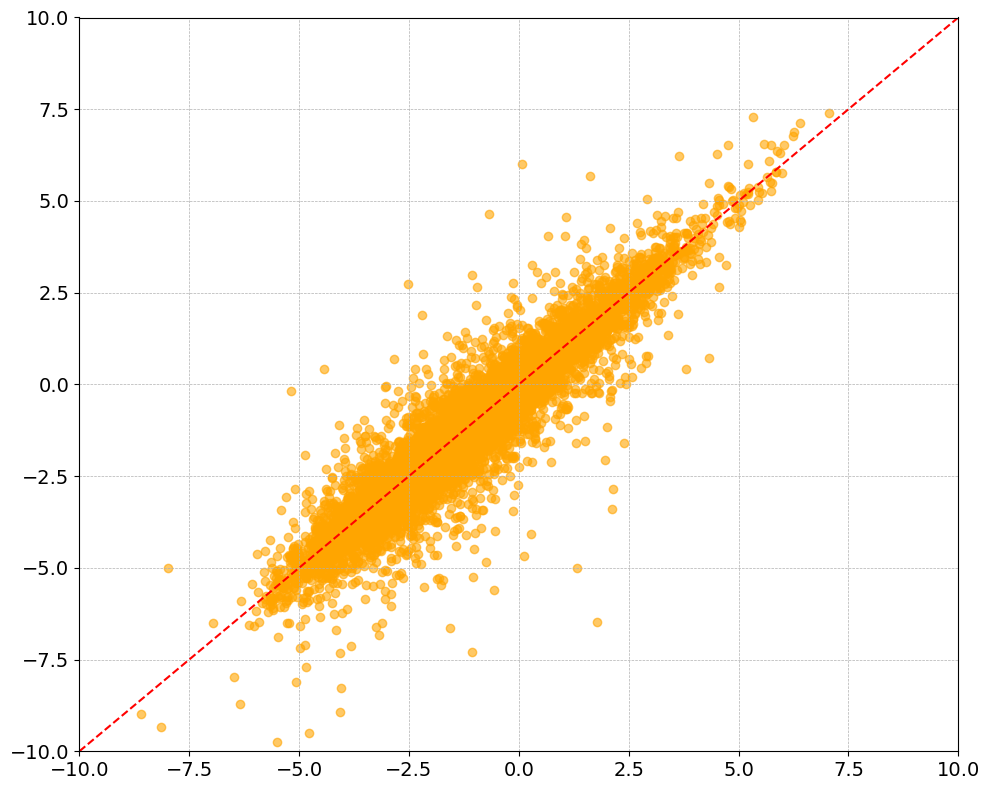

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
npz_path = '/home/liud/Documents/code/ocp/results/is2rse/2025-04-17-21-11-28/is2rfse_predictions_0.npz'
test_path = '/media/liud/Liud_FX2T/dataset/OC20/is2re_100k/select_data/tags1&2/100k/test'
# train_path = '/media/liud/Liud_FX2T/dataset/OC20/is2re_10k/ac_stru/select_data_ads_dis1/train'

# 读取 npz 文件中的数据
data = np.load(npz_path)

# 提取 ids1, ids2 和 energy
sid = np.array(data['ids'].astype(int)) # sid
energy = np.array(data['energy'])

# energy 按照 sid排序
sorted_idx = np.argsort(sid)
sid_sorted = sid[sorted_idx].tolist()
energy_sorted = energy[sorted_idx].tolist()

# 打开 LMDB 文件
env = lmdb.open(test_path, readonly=True)

# 列表用于存储 (sid,  y) 元组
data_list = []

# 从 LMDB 文件中读取数据并提取 sid,和 y 值
with env.begin(write=False) as txn:
    cursor = txn.cursor()
    for key, value in cursor:
        info = pickle.loads(value)
        data_list.append((info.sid ,info.y))
        # data_list.append((info.sid, info.ads_id ,info.y))

# 关闭 LMDB 文件
env.close()

# 将数据转换为 numpy 数组以便于排序
data_array = np.array(data_list, dtype=[('sid', 'i4'), ('y', 'f8')])
# data_array = np.array(data_list, dtype=[('sid', 'i4'), ('ads_id','i4'), ('y', 'f8')])

# 按照 sid 和 fid 对 data_array 进行排序
sorted_data_array = np.sort(data_array, order=['sid'])

# 提取排序后的 sid、fid 和 y 值列表
sid_list = sorted_data_array['sid'].tolist()
test_energy_sorted = sorted_data_array['y'].tolist()

# 创建横坐标和纵坐标
x = energy_sorted
y = test_energy_sorted

plt.figure(figsize=(10, 8))  # 设置图像大小

# 绘制散点图
plt.scatter(x, y, marker='o', color='orange', alpha=0.6)

# 使用seaborn绘制密度图
# sns.kdeplot(x=x, y=y, cmap='Blues', shade=True, bw_adjust=0.5, alpha=0.5)

# 添加 y=x 的虚线
min_val = -10
max_val = 10
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='r', label='y=x')

# 设置坐标轴范围
plt.xlim(-10, 10)
plt.ylim(-10, 10)

# 添加标题和图例
# plt.title('Comparison of Energy List and Test List', fontsize=20)
# plt.xlabel('Predict', fontsize=16)
# plt.ylabel('Truth', fontsize=16)
# plt.legend()

# 设置刻度字体大小
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)

# 显示图形
plt.tight_layout()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


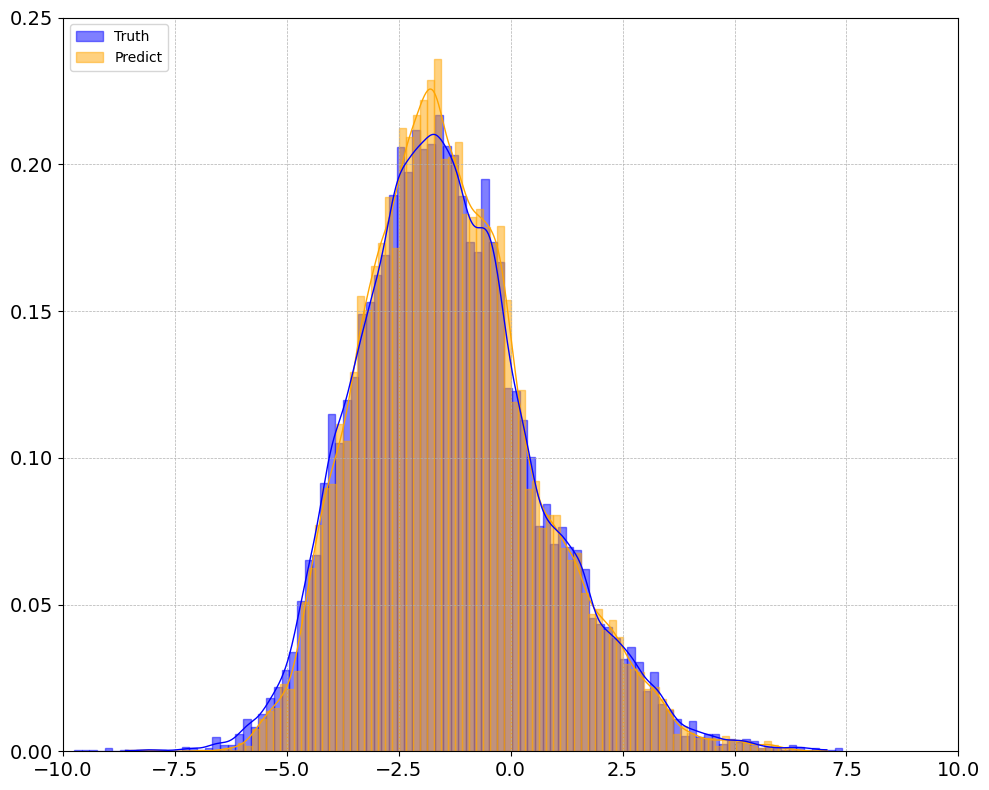

In [67]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

npz_path = '/home/liud/Documents/code/ocp/results/is2rse/2025-04-17-21-11-28/is2rfse_predictions_0.npz'
test_path = '/media/liud/Liud_FX2T/dataset/OC20/is2re_100k/select_data/tags1&2/100k/test'
# train_path = '/media/liud/Liud_FX2T/dataset/OC20/is2re_10k/ac_stru/select_data_ads_dis1/train'

# 读取 npz 文件中的数据
data = np.load(npz_path)

# 提取 ids1, ids2 和 energy
sid = np.array(data['ids'].astype(int)) # sid
energy = np.array(data['energy'])

# energy 按照 sid排序
sorted_idx = np.argsort(sid)
sid_sorted = sid[sorted_idx].tolist()
energy_sorted = energy[sorted_idx].tolist()

# 打开 LMDB 文件
env = lmdb.open(test_path, readonly=True)

# 列表用于存储 (sid,  y) 元组
data_list = []

# 从 LMDB 文件中读取数据并提取 sid,和 y 值
with env.begin(write=False) as txn:
    cursor = txn.cursor()
    for key, value in cursor:
        info = pickle.loads(value)
        data_list.append((info.sid ,info.y))
        # data_list.append((info.sid, info.ads_id ,info.y))

# 关闭 LMDB 文件
env.close()

# 将数据转换为 numpy 数组以便于排序
data_array = np.array(data_list, dtype=[('sid', 'i4'), ('y', 'f8')])
# data_array = np.array(data_list, dtype=[('sid', 'i4'), ('ads_id','i4'), ('y', 'f8')])

# 按照 sid 和 fid 对 data_array 进行排序
sorted_data_array = np.sort(data_array, order=['sid'])

# 提取排序后的 sid、fid 和 y 值列表
sid_list = sorted_data_array['sid'].tolist()
test_energy_sorted = sorted_data_array['y'].tolist()

plt.figure(figsize=(10, 8))  # 设置图像大小



# 绘制真实值的密度柱状图
plt.hist(y, bins=100, density=True, alpha=0.5, color='blue', label='Truth', edgecolor='blue')
# 绘制预测值的密度柱状图
plt.hist(x, bins=100, density=True, alpha=0.5, color='orange', label='Predict', edgecolor='orange')
# 设置坐标轴范围
plt.xlim(-10, 10)
plt.ylim(0, 0.25)


# 使用gaussian_kde进行拟合并绘制拟合曲线（预测值）
kde_x = gaussian_kde(x, bw_method=0.1)  # bw_method控制拟合平滑度
x_vals = np.linspace(min(x), max(x), 1000)  # x轴的取值范围
plt.plot(x_vals, kde_x(x_vals), color='orange', lw=1)

# 使用gaussian_kde进行拟合并绘制拟合曲线（真实值）
kde_y = gaussian_kde(y, bw_method=0.1)
plt.plot(x_vals, kde_y(x_vals), color='blue', lw=1)


# 设置刻度字体大小
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)

# 显示图形
plt.tight_layout()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 显示图例
plt.legend(loc='upper left')

plt.show()

In [24]:
difference = [abs(e - t) for e, t in zip(energy_sorted, test_energy_sorted)]
filtered_difference = [d for d in difference if d <= 0.3]
len(filtered_difference)
# 输出结果
# print(difference)

5956

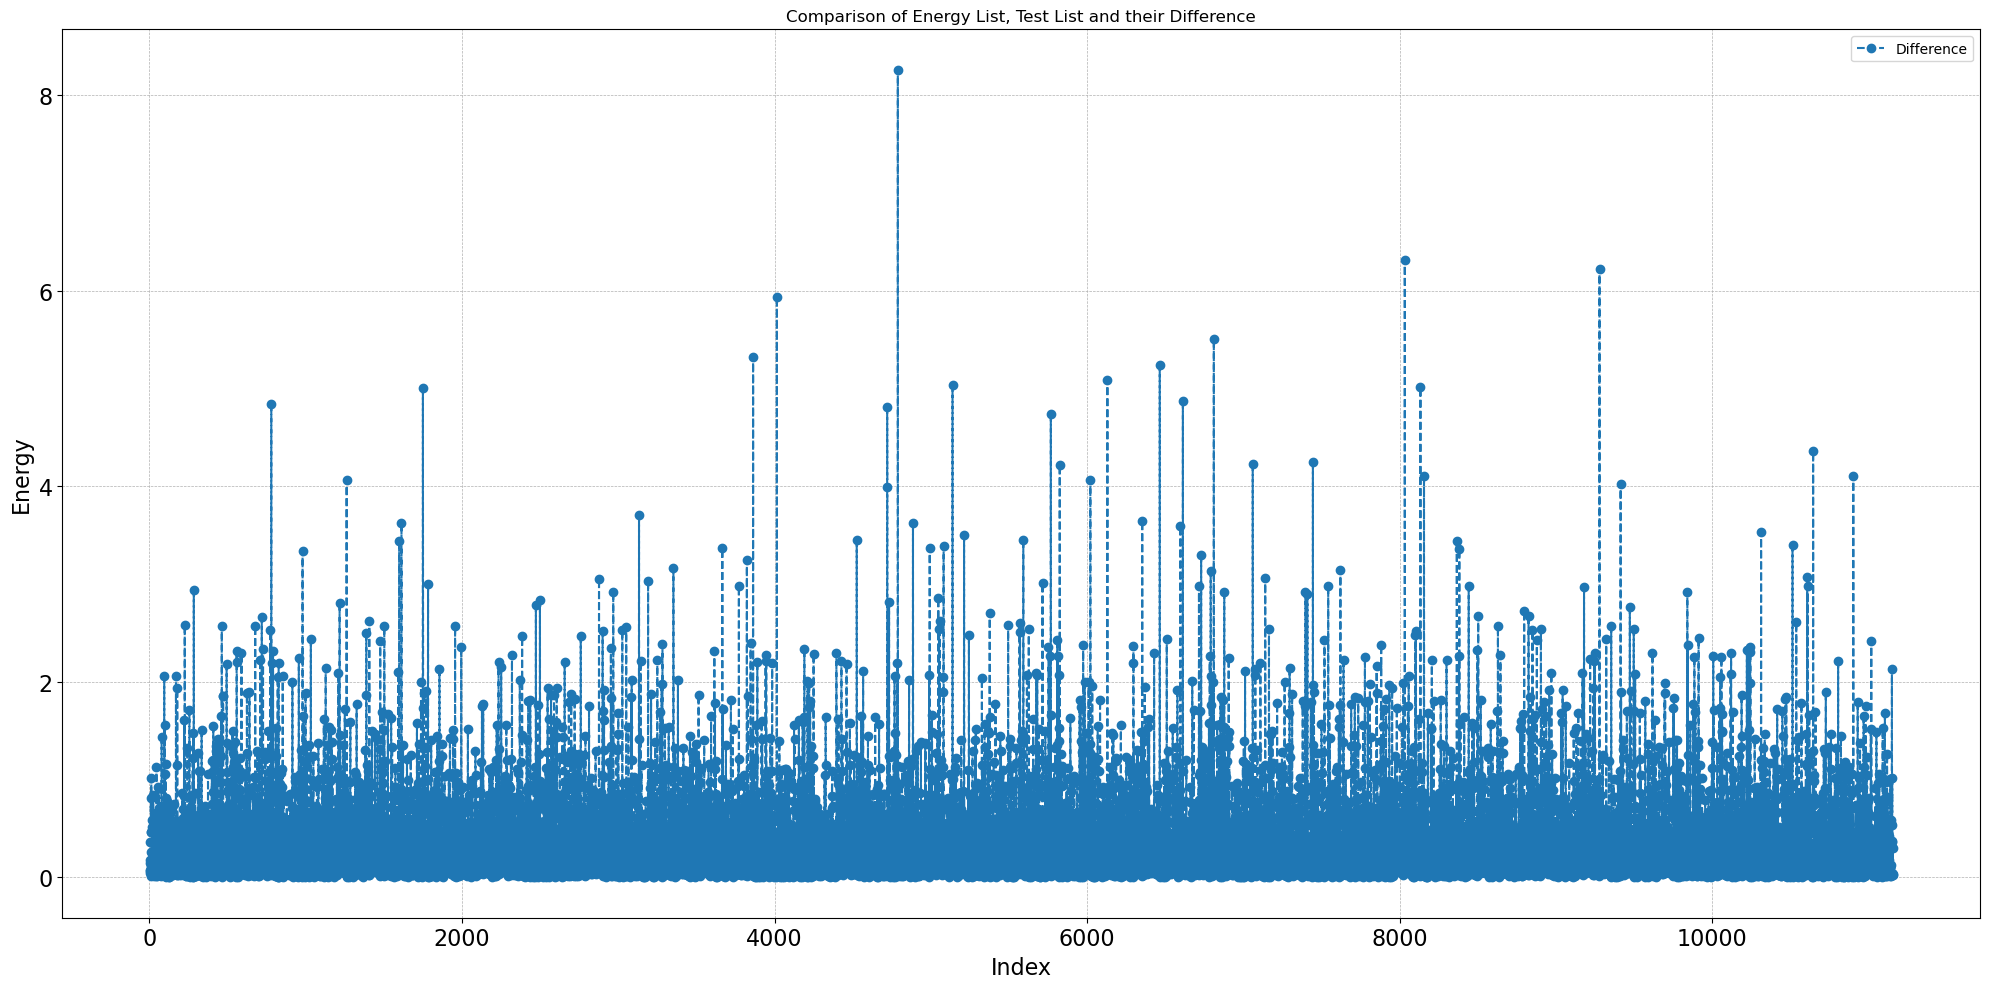

In [25]:
x = range(1, len(energy_sorted) + 1)
plt.figure(figsize=(20, 10))  # 设置图像大小
# 做差值
plt.plot(x, difference, label='Difference', marker='o', linestyle='--')
plt.title('Comparison of Energy List, Test List and their Difference')
plt.xlabel('Index', fontsize=16)
plt.ylabel('Energy', fontsize=16)
plt.legend()

plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)

# 显示图形
plt.tight_layout()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [26]:
# def mean_absolute_error(data_list):
#     # 计算平均绝对误差
#     mae = sum(data_list) / len(data_list)
#     return mae
# 
# # 示例
# print(mean_absolute_error(difference))

import numpy as np

def calculate_errors(data_list):
    # 计算平均绝对误差 (MAE)
    mae = np.mean(np.abs(data_list))
    
    # 计算均方误差 (MSE)
    mse = np.mean(np.square(data_list))
    
    # 计算均方根误差 (RMSE)
    rmse = np.sqrt(mse)
    
    return mae, mse, rmse

mae, mse, rmse = calculate_errors(difference)

print(f"MAE: {mae}") 
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

MAE: 0.42925312100128304
MSE: 0.4424297789201389
RMSE: 0.6651539512925853


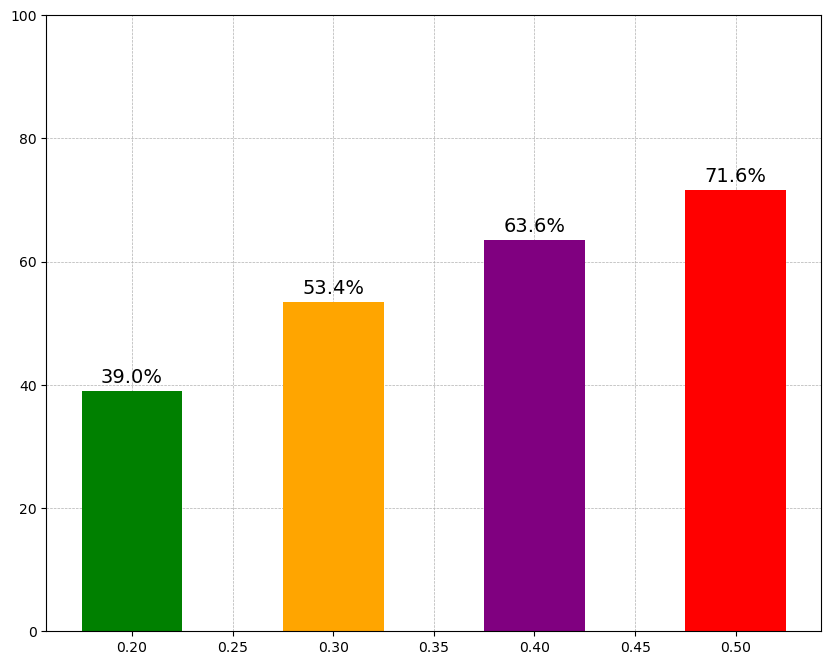

In [66]:
# n_difference = sum(1 for value in difference if value < 0.3)
# 
# # 计算比例
# ratio_diff = n_difference / len(difference)
# ratio_diff
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

npz_path = '/home/liud/Documents/code/ocp/results/is2rse/2025-04-17-21-11-28/is2rfse_predictions_0.npz'
test_path = '/media/liud/Liud_FX2T/dataset/OC20/is2re_100k/select_data/tags1&2/100k/test'
# train_path = '/media/liud/Liud_FX2T/dataset/OC20/is2re_10k/ac_stru/select_data_ads_dis1/train'

# 读取 npz 文件中的数据
data = np.load(npz_path)

# 提取 ids1, ids2 和 energy
sid = np.array(data['ids'].astype(int)) # sid
energy = np.array(data['energy'])

# energy 按照 sid排序
sorted_idx = np.argsort(sid)
sid_sorted = sid[sorted_idx].tolist()
energy_sorted = energy[sorted_idx].tolist()

# 打开 LMDB 文件
env = lmdb.open(test_path, readonly=True)

# 列表用于存储 (sid,  y) 元组
data_list = []

# 从 LMDB 文件中读取数据并提取 sid,和 y 值
with env.begin(write=False) as txn:
    cursor = txn.cursor()
    for key, value in cursor:
        info = pickle.loads(value)
        data_list.append((info.sid ,info.y))
        # data_list.append((info.sid, info.ads_id ,info.y))

# 关闭 LMDB 文件
env.close()

# 将数据转换为 numpy 数组以便于排序
data_array = np.array(data_list, dtype=[('sid', 'i4'), ('y', 'f8')])
# data_array = np.array(data_list, dtype=[('sid', 'i4'), ('ads_id','i4'), ('y', 'f8')])

# 按照 sid 和 fid 对 data_array 进行排序
sorted_data_array = np.sort(data_array, order=['sid'])

# 提取排序后的 sid、fid 和 y 值列表
sid_list = sorted_data_array['sid'].tolist()
test_energy_sorted = sorted_data_array['y'].tolist()


# 定义不同的绝对误差阈值
thresholds = [0.2, 0.3, 0.4, 0.5]

# 计算每个阈值下的成功率
success_rates = [sum(1 for value in difference if value < threshold) / len(difference) for threshold in thresholds]

# 转换为百分比
success_rates_percentage = [rate * 100 for rate in success_rates]

# 定义柱子的颜色
colors = ['green', 'orange', 'purple','red']

# 创建条形图
fig, ax = plt.subplots(figsize=(10, 8))
plt.grid(True, which='both', linestyle='--', linewidth=0.5,  zorder=0)
bars = ax.bar(thresholds, success_rates_percentage, color=colors, width=0.05, zorder=2)

# 添加数据标签
for bar, rate in zip(bars, success_rates_percentage):
    height = bar.get_height()
    ax.annotate(f'{rate:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=14)

# 设置标题和标签
ax.set_ylim(0, 100)

# 显示图形
plt.show()

In [150]:
import lmdb
import pickle
import numpy as np

# 读取 npz 文件中的数据
data = np.load('/home/zjy/code/mycode/ocp/data_analyse/2024-07-22-09-04-00/is2re_predictions.npz')

# 提取 ids1, ids2 和 energy
ids1 = data['ids1']
ids2 = data['ids2']
energy = data['energy']

# 将 ids1 和 ids2 转换为数值
ids1_numeric = ids1.astype(int)
ids2_numeric = ids2.astype(int)

# 将 ids1 和 ids2 合并为一个键，用于排序
combined_ids = list(zip(ids1_numeric, ids2_numeric))

# 创建一个索引列表，先根据 ids1_numeric 排序，然后再根据 ids2_numeric 排序
sorted_indices = np.lexsort((ids2_numeric, ids1_numeric))

# 根据排序后的索引获取排序后的 energy 列表
sorted_energy = energy[sorted_indices]

# 打开 LMDB 文件以读取数据
env = lmdb.open('/home/zjy/code/mycode/ocp/test_data/all_CNN/test/', readonly=True)

# 列表用于存储 (sid, fid, y) 元组
data_list = []

# 从 LMDB 文件中读取数据并提取 sid, fid 和 y 值
with env.begin(write=False) as txn:
    cursor = txn.cursor()
    for key, value in cursor:
        info = pickle.loads(value)
        sid = info.sid
        fid = info.fid
        y = info.y
        data_list.append((sid, fid, y, key, value))

# 将 data_list 转换为 numpy 数组
data_array = np.array(data_list, dtype=[('sid', 'i4'), ('fid', 'i4'), ('y', 'f8'), ('key', 'O'), ('value', 'O')])

# 按照 sid 和 fid 对 data_array 进行排序
sorted_data_array = np.sort(data_array, order=['sid', 'fid'])

# 提取排序后的 y 列表以及 key 和 value
sorted_y = sorted_data_array['y']
sorted_keys = sorted_data_array['key']
sorted_values = sorted_data_array['value']

# 筛选出符合条件的数据
filtered_data = []

for i in range(len(sorted_y)):
    energy = sorted_energy[i]  # 获取对应的 energy
    y = sorted_y[i]
    key = sorted_keys[i]
    value = sorted_values[i]
    
    # 判断 energy 和 y 的绝对差值是否小于 0.35
    if 0.5 < abs(y - energy) < 0.7:
        filtered_data.append((key, value))  # 保存符合条件的键值对

# 关闭 LMDB 文件
env.close()

# 打开一个新的 LMDB 文件以存储筛选后的数据
env_new = lmdb.open('/home/zjy/code/mycode/ocp/test_data/all_CNN/test/test_050_070', map_size=int(1e12))

with env_new.begin(write=True) as txn_new:
    for new_key, (old_key, value) in enumerate(filtered_data):
        new_key_bytes = str(new_key).encode('ascii')  # 将新键转换为字节类型
        txn_new.put(new_key_bytes, value)  # 使用新键存储

# 关闭新的 LMDB 文件
env_new.close()

print(f"Filtered {len(filtered_data)} entries and stored in the new LMDB file with sequential keys.")


Filtered 99 entries and stored in the new LMDB file with sequential keys.
